# Evaluate Dataset Coverage

This notebook loads dataset CSV files from a folder and plots `qvel` vs `qtorque_cmd`.

For the current PD datasets, `qact` is the target position. Use `qtorque_cmd` as the torque-like command for coverage and system-identification checks.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

/home/slava/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


## Configuration

Set `DATASET_DIR` to the folder containing current PD dataset CSV files. The notebook plots only files that contain `qtorque_cmd`; older files without this column are skipped.

In [2]:
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "scripts" else Path.cwd()
DATASET_DIR = PROJECT_ROOT / "data" / "raw_pd"

BASE_COLUMNS = {"time_s", "qpos", "qvel"}
TORQUE_COLUMN = "qtorque_cmd"
POINT_ALPHA = 0.35
POINT_SIZE = 8

In [3]:
def load_dataset_folder(dataset_dir: Path = DATASET_DIR) -> dict[str, pd.DataFrame]:
    csv_paths = sorted(dataset_dir.glob("*.csv"))
    if not csv_paths:
        raise FileNotFoundError(f"No CSV files found in {dataset_dir}")

    datasets = {}
    skipped = []
    for path in csv_paths:
        df = pd.read_csv(path)
        if TORQUE_COLUMN not in df.columns:
            skipped.append(path.name)
            continue

        missing = BASE_COLUMNS - set(df.columns)
        if missing:
            raise ValueError(f"{path} is missing required columns: {sorted(missing)}")
        datasets[path.stem] = df

    if not datasets:
        raise ValueError(f"No CSV files with {TORQUE_COLUMN!r} found in {dataset_dir}")
    if skipped:
        print(f"Skipped {len(skipped)} files without {TORQUE_COLUMN}: {skipped}")
    return datasets


datasets = load_dataset_folder()
print(f"Loaded {len(datasets)} dataset files with {TORQUE_COLUMN} from {DATASET_DIR}")

summary = pd.DataFrame(
    [
        {
            "run": name,
            "samples": len(df),
            "duration_s": df["time_s"].iloc[-1] - df["time_s"].iloc[0],
            "qvel_min": df["qvel"].min(),
            "qvel_max": df["qvel"].max(),
            "qtorque_cmd_min": df[TORQUE_COLUMN].min(),
            "qtorque_cmd_max": df[TORQUE_COLUMN].max(),
        }
        for name, df in datasets.items()
    ]
)
summary

Skipped 3 files without qtorque_cmd: ['pd_chirp_qpos_amp0p6_0p1_2hz.csv', 'pd_sine_qpos_amp1p0_0p5hz.csv', 'pd_steps_qpos_amp0p5_500ms_s1.csv']
Loaded 18 dataset files with qtorque_cmd from /home/slava/projects/encos-sys-id/data/raw_pd


,run,samples,duration_s,qvel_min,qvel_max,qtorque_cmd_min,qtorque_cmd_max
0,pd_chirp_qpos_amp0p2_0p1_1p5hz_kp8_kd1,10000,9.999,-2.523077,2.479120,-5.218926,5.596867
1,pd_chirp_qpos_amp0p4_0p1_1p5hz_kp8_kd1,10000,9.999,-4.764835,4.465935,-9.816702,10.811264
2,pd_chirp_qpos_amp0p4_0p1_2hz_kp10_kd1,12000,11.999,-5.476923,5.371429,-12.512404,12.598242
3,pd_chirp_qpos_amp0p6_0p1_2hz_kp10_kd1,12000,11.999,-7.147253,7.305494,-23.332429,24.461607
4,pd_hold_qpos0_kp6_kd0p8,3000,2.999,-0.026373,0.026373,-0.021098,0.021098
5,pd_linear_qpos_0_to_1p2_8s_kp6_kd0p8,8000,7.999,-0.043957,0.421978,0.114767,5.010958
6,pd_pulses_qpos_amp0p4_150ms_800ms_s3_kp30_kd3,10000,9.999,-1.617582,1.186813,-9.970793,9.462770
7,pd_pulses_qpos_amp0p4_150ms_800ms_s3_kp8_kd1,10000,9.999,-0.738462,0.430769,-2.939381,2.067445
8,pd_pulses_qpos_amp0p6_150ms_800ms_s3_kp20_kd1,10000,9.999,-1.978022,1.951649,-9.288273,8.773485
9,pd_pulses_qpos_amp1p0_400ms_800ms_s3_kp20_kd1,10000,9.999,-6.830770,4.931868,-22.692865,19.764338


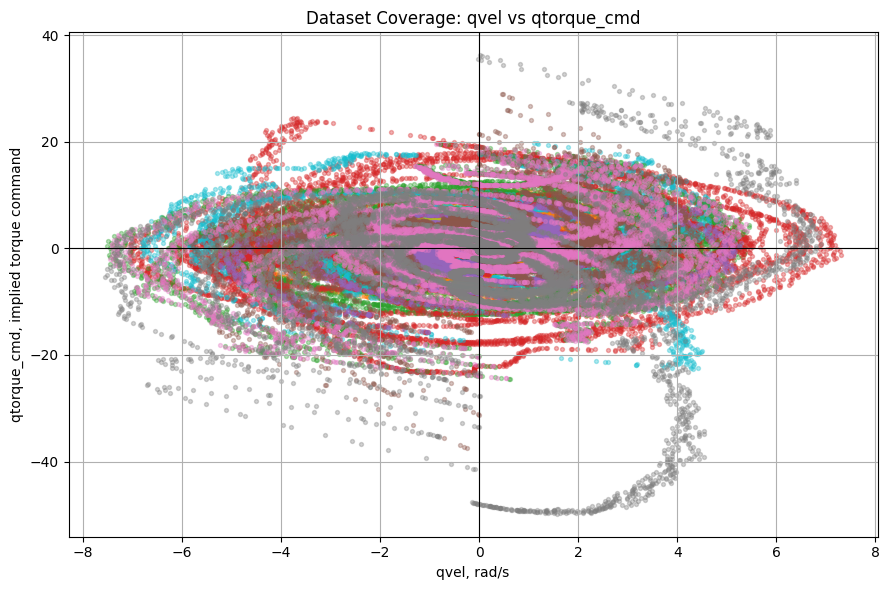

In [4]:
fig, ax = plt.subplots(figsize=(9, 6))

for name, df in datasets.items():
    ax.scatter(
        df["qvel"],
        df["qtorque_cmd"],
        s=POINT_SIZE,
        alpha=POINT_ALPHA,
        label=name,
    )

ax.axhline(0, color="black", linewidth=0.8)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("qvel, rad/s")
ax.set_ylabel("qtorque_cmd, implied torque command")
ax.set_title("Dataset Coverage: qvel vs qtorque_cmd")
ax.grid()
# ax.legend()
plt.tight_layout()
plt.show()

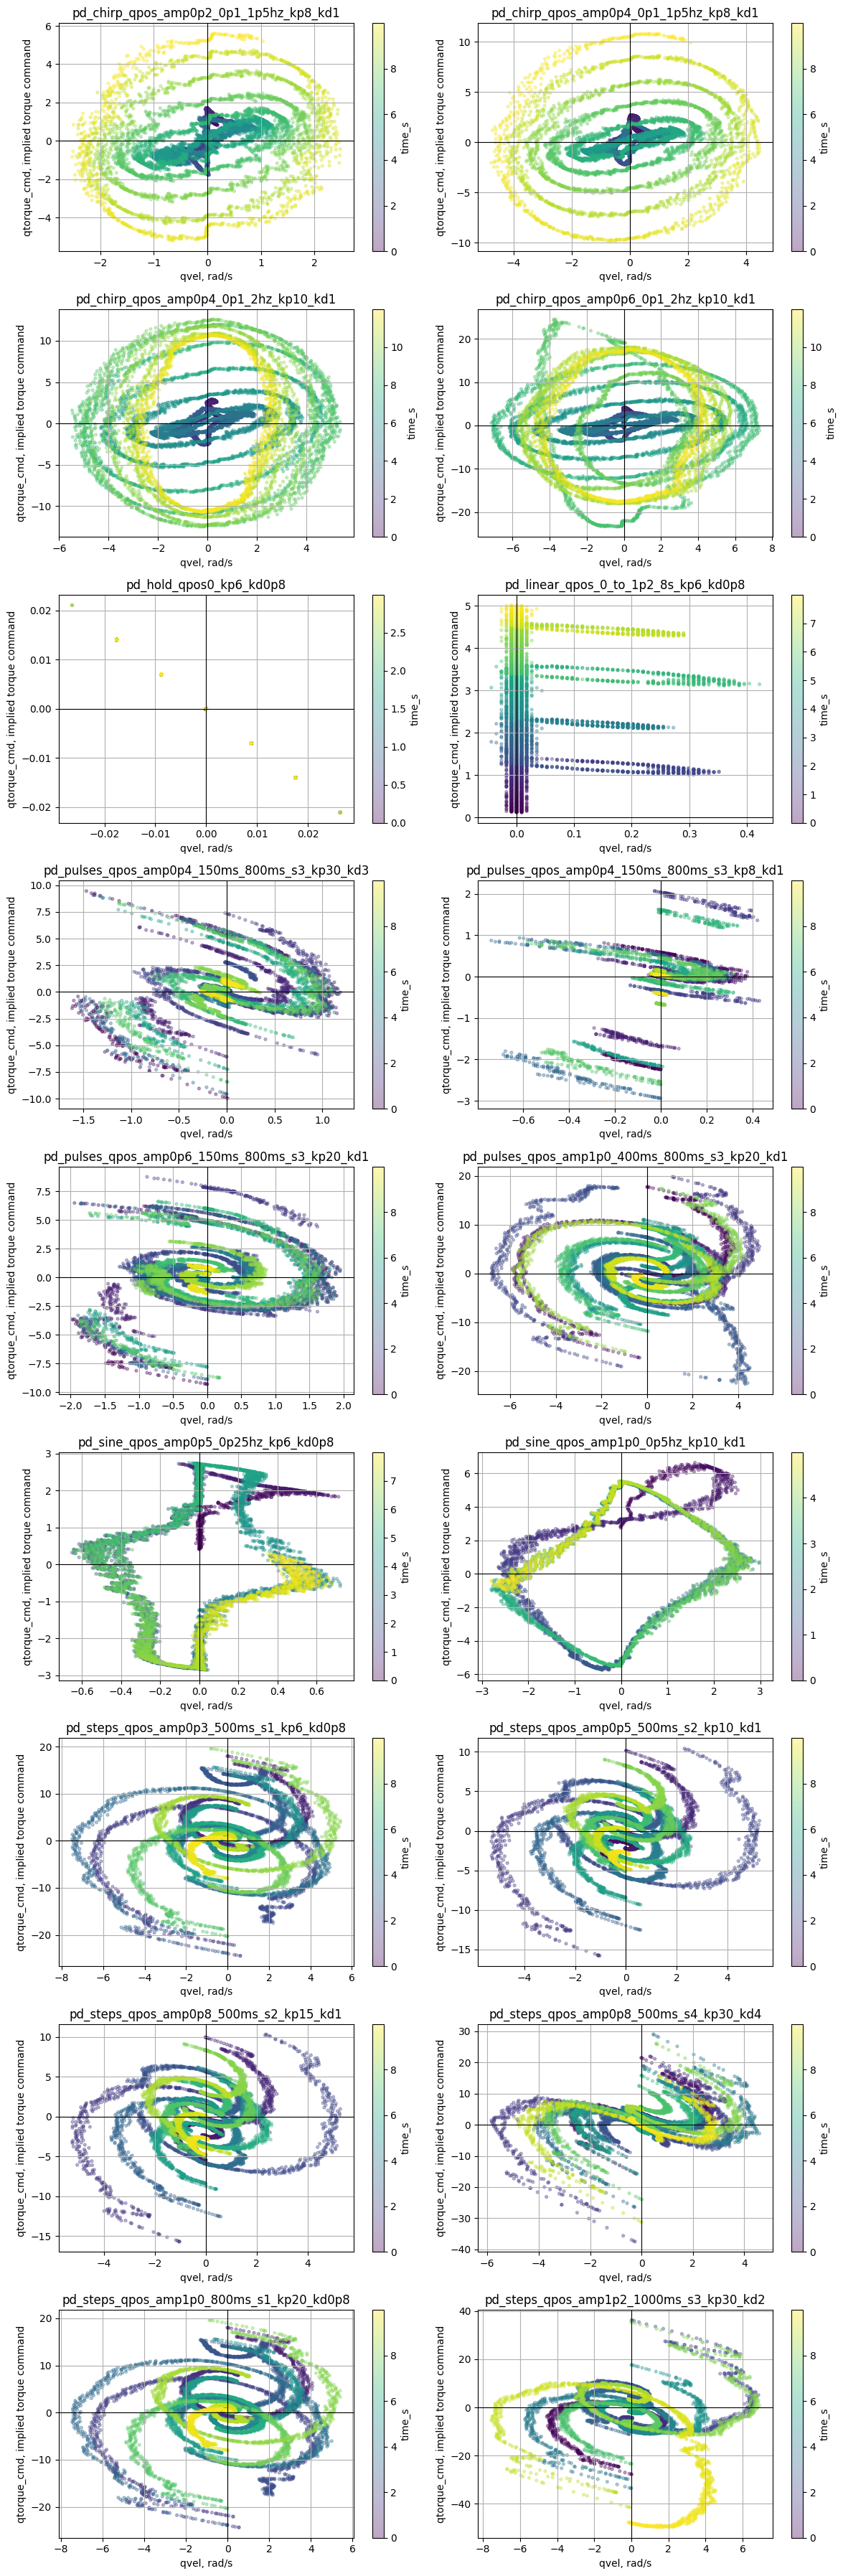

In [5]:
cols = 2
rows = int(np.ceil(len(datasets) / cols))
fig, axes = plt.subplots(rows, cols, figsize=(12, 4 * rows), squeeze=False)

for axis, (name, df) in zip(axes.ravel(), datasets.items()):
    scatter = axis.scatter(
        df["qvel"],
        df["qtorque_cmd"],
        c=df["time_s"],
        cmap="viridis",
        s=POINT_SIZE,
        alpha=POINT_ALPHA,
    )
    axis.axhline(0, color="black", linewidth=0.8)
    axis.axvline(0, color="black", linewidth=0.8)
    axis.set_title(name)
    axis.set_xlabel("qvel, rad/s")
    axis.set_ylabel("qtorque_cmd, implied torque command")
    axis.grid()
    fig.colorbar(scatter, ax=axis, label="time_s")

for axis in axes.ravel()[len(datasets):]:
    axis.axis("off")

plt.tight_layout()
plt.show()